In [1]:
from datasets import load_dataset
dataset = load_dataset("cnn_dailymail", '3.0.0', split="train[:10]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


In [2]:
print(dataset[0]['article'])
print("\n\n")
print(dataset[0]['highlights'])

LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don't think I'll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one movie on the UK box office chart. Details of how

In [3]:
from transformers import pipeline
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

summary={}
pipe = pipeline("summarization", model = 'ubikpt/t5-small-finetuned-cnn', device=device)
output = pipe(dataset[0]['article'])
summary['T5-small-finetuned-cnn'] = output[0]['summary_text']

pipe = pipeline("summarization", model = 'facebook/bart-large-cnn', device=device)
output = pipe(dataset[0]['article'])
summary['facebook/bart-large-cnn'] = output[0]['summary_text']
print(summary)

Device set to use cuda
Token indices sequence length is longer than the specified maximum sequence length for this model (638 > 512). Running this sequence through the model will result in indexing errors
Device set to use cuda


{'T5-small-finetuned-cnn': 'Harry Potter star Daniel Radcliffe says he has no plans to fritter his cash away . The actor has filmed a TV movie about author Rudyard Kipling', 'facebook/bart-large-cnn': "Harry Potter star Daniel Radcliffe turns 18 on Monday. He gains access to a reported £20 million ($41.1 million) fortune. Radcliffe's earnings from the first five Potter films have been held in a trust fund. Details of how he'll mark his landmark birthday are under wraps."}


In [4]:
for model in summary:
    print(f"Model: {model}")
    print(f"Summary: {summary[model]}")
    print("\n\n")

Model: T5-small-finetuned-cnn
Summary: Harry Potter star Daniel Radcliffe says he has no plans to fritter his cash away . The actor has filmed a TV movie about author Rudyard Kipling



Model: facebook/bart-large-cnn
Summary: Harry Potter star Daniel Radcliffe turns 18 on Monday. He gains access to a reported £20 million ($41.1 million) fortune. Radcliffe's earnings from the first five Potter films have been held in a trust fund. Details of how he'll mark his landmark birthday are under wraps.





In [24]:
torch.cuda.empty_cache()

In [25]:
# fine-tuning summarization model on a custom dataset
samsum = load_dataset("knkarthick/samsum")
samsum

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 14731
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 818
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary'],
        num_rows: 819
    })
})

In [26]:
import pandas as pd
dialogue_len = [len(dialogue) for dialogue in samsum['train']['dialogue']]
summary_len = [len(summary) for summary in samsum['train']['summary']]


array([[<Axes: title={'center': 'dialogue_len'}>,
        <Axes: title={'center': 'summary_len'}>]], dtype=object)

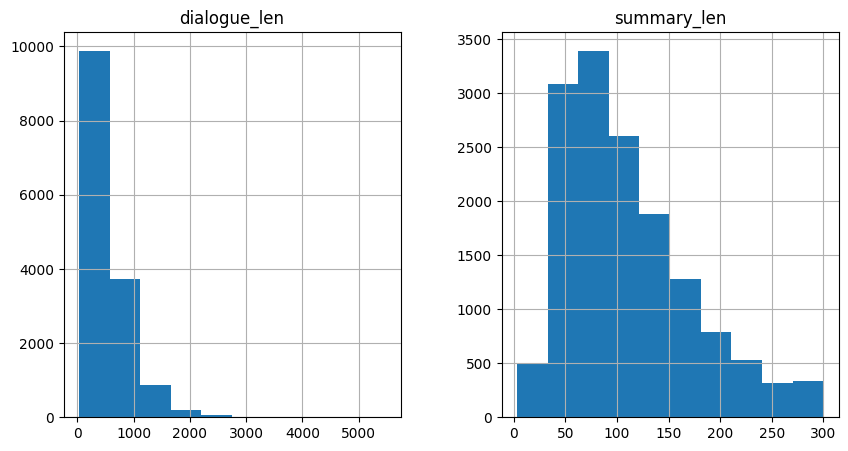

In [27]:
data = pd.DataFrame({'dialogue_len': dialogue_len, 'summary_len': summary_len})
data.hist(figsize=(10,5))

Model Loading and Tokenization

In [28]:
from transformers import T5Tokenizer, T5ForConditionalGeneration

tokenizer = T5Tokenizer.from_pretrained("google/flan-t5-base")
model = T5ForConditionalGeneration.from_pretrained("google/flan-t5-base")

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [29]:
def tokenize_batch(batch):
    encoding = tokenizer(batch['dialogue'], text_target=batch['summary'], truncation=True, padding=True, return_tensors='pt', max_length=1024)
    return encoding

In [30]:
samsum_pt = samsum.map(tokenize_batch, batched=True)

Map:   0%|          | 0/14731 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

Map:   0%|          | 0/819 [00:00<?, ? examples/s]

In [33]:
max_length = max([len(input_ids) for input_ids in samsum_pt['train']['input_ids']])
print(f"Max input length: {max_length}")

Max input length: 1024


Model Training

In [ ]:
from transformers import DataCollatorForSeq2Seq
from transformers import Trainer, TrainingArguments

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

args = TrainingArguments(
    num_train_epochs=4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    eval_strategy='epoch',
    save_strategy='epoch',
    weight_decay=0.01,
    learning_rate=2e-5,
    gradient_accumulation_steps=500
)

trainer = Trainer(
    model=model,
    args=args,
    tokenizer=tokenizer,
    data_collator=data_collator,
    train_dataset=samsum_pt['train'],
    eval_dataset=samsum_pt['validation']
)

trainer.train()

/tmp/ipython-input-1867450769.py:17: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


OutOfMemoryError: CUDA out of memory. Tried to allocate 20.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 3.81 MiB is free. Including non-PyTorch memory, this process has 14.56 GiB memory in use. Of the allocated memory 14.37 GiB is allocated by PyTorch, and 59.19 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)